**Цель работы**
1. Освоить методы обнаружения выбросов на основе статистических
критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом
предметной области.


**Задание:**

В рамках лабораторной работы необходимо выполнить анализ набора данных и
реализовать несколько методов обнаружения аномалий.

Для работы нужно использовать самостоятельно выбранный числовой датасет,
можно продолжить с датасетом, который был выбран в Лабораторной работе №1.


# Задание 1. Загрузка и профилирование данных
1. Загрузить датасет.
2. Выполнить:
- df.info()
- df.describe()
3. Проанализировать:
- наличие пропусков,
- диапазоны значений,
- подозрительные экстремальные значения.

Для двух числовых признаков выполнить визуальный анализ:
1. Построить гистограмму.
2. Построить boxplot.
3. Сделать вывод о возможных выбросах.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
upl = files.upload()
# Загрузка данных
df = pd.read_csv('toyota.csv')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')


Saving toyota.csv to toyota.csv
Размер датасета: 6738 строк, 9 столбцов


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [ ]:
print("Проанализировать:")

print("="*60)
print("Наличие пропусков")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

print("="*60)
print("Диапазоны значений")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col:12} -> мин: {min_val:10.2f}, макс: {max_val:10.2f}")

print("="*60)
print("Подозрительные экстремальные значения")

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    threshold = 3 * std_val
    outliers = df[(df[col] < mean_val - threshold) | (df[col] > mean_val + threshold)]

    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Среднее: {mean_val:.2f}")
        print(f"  Подозрительные: {outliers[col].sort_values(ascending=False).head().tolist()}")

Проанализировать:
Наличие пропусков
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Всего пропусков: 0
Диапазоны значений
year         -> мин:    1998.00, макс:    2020.00
price        -> мин:     850.00, макс:   59995.00
mileage      -> мин:       2.00, макс:  174419.00
tax          -> мин:       0.00, макс:     565.00
mpg          -> мин:       2.80, макс:     235.00
engineSize   -> мин:       0.00, макс:       4.50
Подозрительные экстремальные значения

year:
  Среднее: 2016.75
  Подозрительные: [2010, 2010, 2010, 2010, 2010]

price:
  Среднее: 12522.39
  Подозрительные: [59995, 54991, 54550, 52990, 52291]

mileage:
  Среднее: 22857.41
  Подозрительные: [174419, 167054, 160000, 150000, 148371]

tax:
  Среднее: 94.70
  Подозрительные: [565, 555, 540, 330, 330]

mpg:
  Среднее: 63.04
  Подозрительные: [235.0, 235.0, 235.0, 235.0, 235.0]

engineSize:
  Среднее

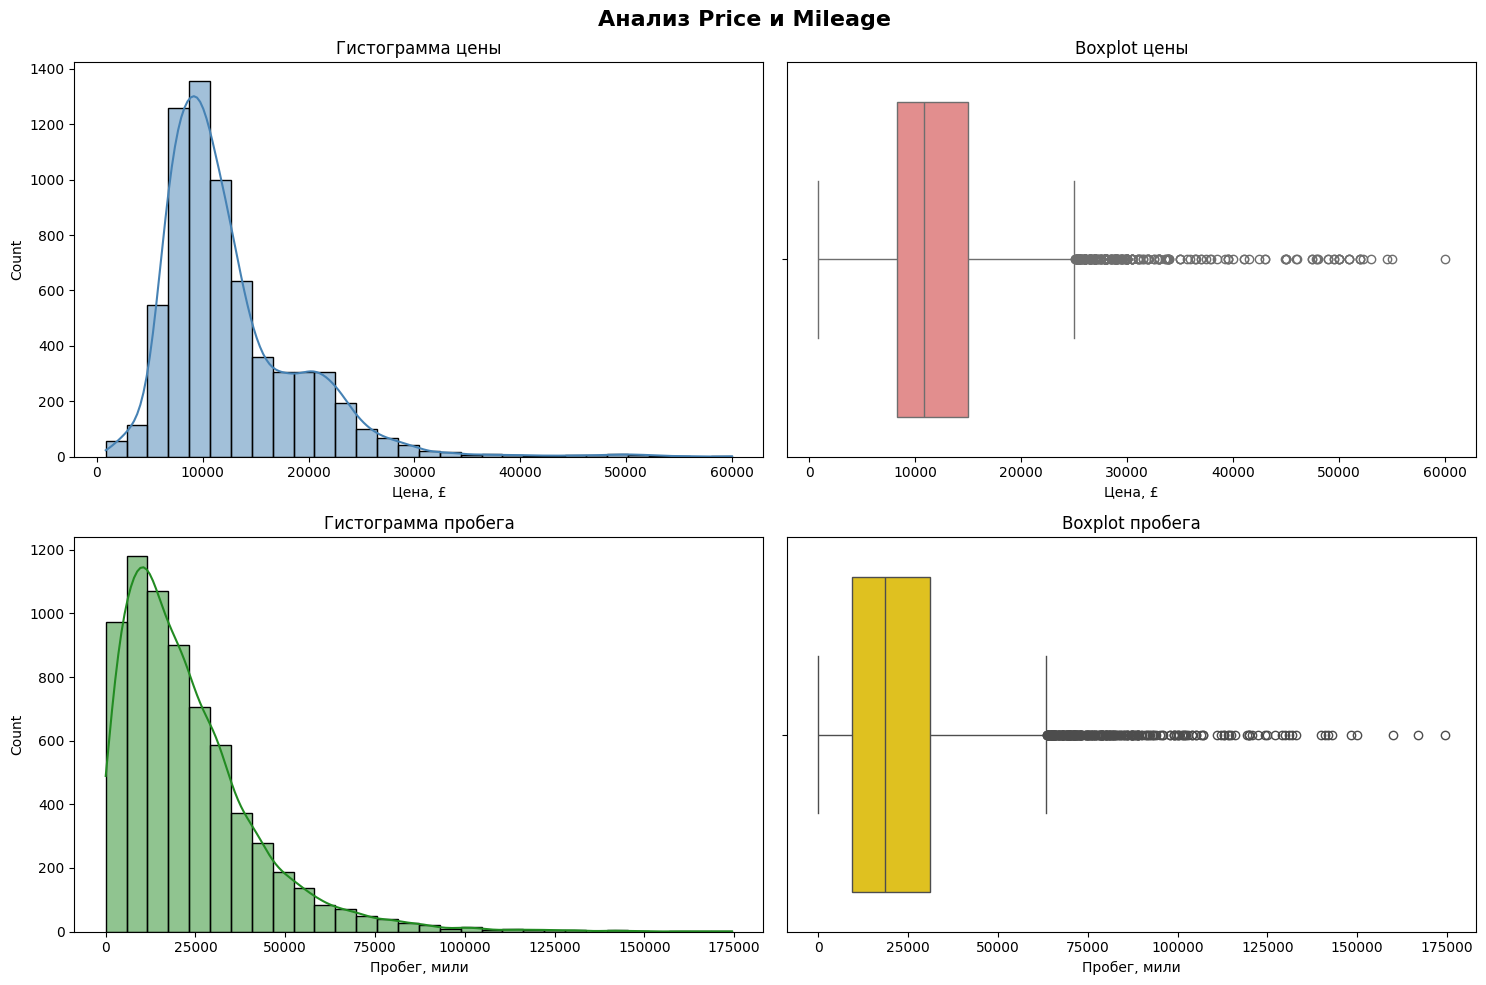

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Анализ Price и Mileage', fontsize=16, fontweight='bold')

sns.histplot(df['price'].dropna(), kde=True, bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Гистограмма цены')
axes[0,0].set_xlabel('Цена, £')

sns.boxplot(x=df['price'].dropna(), ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Boxplot цены')
axes[0,1].set_xlabel('Цена, £')

sns.histplot(df['mileage'].dropna(), kde=True, bins=30, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Гистограмма пробега')
axes[1,0].set_xlabel('Пробег, мили')

sns.boxplot(x=df['mileage'].dropna(), ax=axes[1,1], color='gold')
axes[1,1].set_title('Boxplot пробега')
axes[1,1].set_xlabel('Пробег, мили')

plt.tight_layout()
plt.show()


1. Признак PRICE (цена):
   - Распределение имеет правостороннюю асимметрию (длинный правый "хвост")
   - Большинство автомобилей (около 75%) стоят в диапазоне 5000-20000 £
   - На boxplot'е отчетливо видны точки за пределами верхнего "уса"
   - Это указывает на наличие выбросов в виде аномально дорогих автомобилей
   - Примеры выбросов: автомобили стоимостью > 30000 £

2. Признак MILEAGE (пробег):
   - Также наблюдается правосторонняя асимметрия
   - Основная масса автомобилей имеет пробег до 60000 миль
   - На boxplot'е видно множество точек выше верхнего "уса"
   - Выбросы - автомобили с аномально большим пробегом (> 100000 миль)
   - Также присутствуют выбросы снизу (автомобили с нулевым пробегом - новые)

   ------

1. Признак PRICE (цена):
   - На гистограмме виден длинный правый хвост
   - На boxplot есть точки за верхним усом
   - Вывод: есть выбросы в виде очень дорогих автомобилей

2. Признак MILEAGE (пробег):
   - На гистограмме также правый хвост
   - На boxplot много точек выше верхнего уса
   - Вывод: есть выбросы в виде автомобилей с большим пробегом

# Задание 2. Проверка нормальности распределения
Для выбранных признаков:
1. Вычислить описательные характеристики:
- среднее,
- медиану,
- стандартное отклонение,
- коэффициент асимметрии,
- коэффициент эксцесса.


In [ ]:
from scipy.stats import skew, kurtosis, shapiro, probplot

# Выбираем те же признаки
feature1 = 'price'
feature2 = 'mileage'

for col in [feature1, feature2]:
    data = df[col].dropna()
    print(f"\n{col.upper()}:")
    print(f"  Среднее: {data.mean():.2f}")
    print(f"  Медиана: {data.median():.2f}")
    print(f"  Стд отклонение: {data.std():.2f}")
    print(f"  Асимметрия: {skew(data):.4f}")
    print(f"  Эксцесс: {kurtosis(data):.4f}")


PRICE:
  Среднее: 12522.39
  Медиана: 10795.00
  Стд отклонение: 6345.02
  Асимметрия: 1.8163
  Эксцесс: 5.8053

MILEAGE:
  Среднее: 22857.41
  Медиана: 18513.00
  Стд отклонение: 19125.46
  Асимметрия: 1.9005
  Эксцесс: 6.0614



2. Выполните графический анализ
- Постройте QQ-график.
- Сравните форму распределения с нормальным.


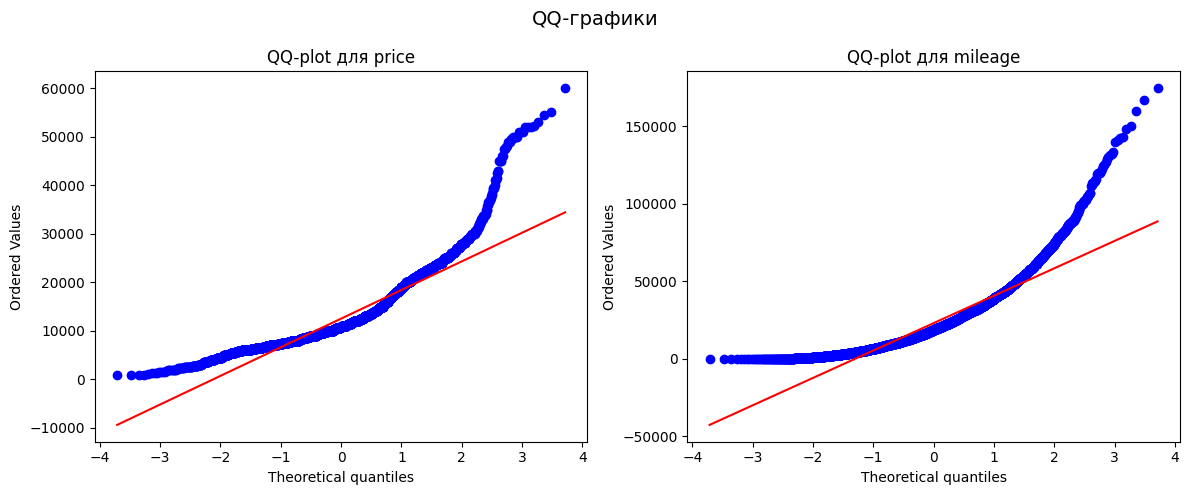

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('QQ-графики', fontsize=14)

probplot(df[feature1].dropna(), dist="norm", plot=axes[0])
axes[0].set_title(f'QQ-plot для {feature1}')

probplot(df[feature2].dropna(), dist="norm", plot=axes[1])
axes[1].set_title(f'QQ-plot для {feature2}')

plt.tight_layout()
plt.show()

Сравнение с нормальным распределением:
- Точки должны лежать на красной прямой
- Отклонение от прямой указывает на ненормальность
- На графиках видно сильное отклонение в хвостах

3. Проверьте нормальность распределения признаков с помощью критерия
Шапиро–Уилка

Сформулируйте гипотезы:
* **H0: выборка подчиняется нормальному распределению**
* **H1: выборка не подчиняется нормальному распределению**

Уровень значимости: α = 0.05
Сделать вывод о принятии или отклонении гипотезы H0

In [ ]:
for col in [feature1, feature2]:
    data = df[col].dropna()
    # Для больших выборок берем первые 2000 записей
    if len(data) > 2000:
        data_sample = data.sample(n=2000, random_state=42)
    else:
        data_sample = data

    stat, p_value = shapiro(data_sample) # Критерий Шапиро-Уилка

    print(f"{col.upper()}:")
    print(f"  Статистика: {stat:.4f}")
    print(f"  p-value: {p_value:.4f}")

    if p_value > 0.05:
        print(f"  РЕЗУЛЬТАТ: p-value > 0.05 → НЕ отвергаем H0")
        print(f"  Вывод: данные могут быть нормальными\n")
    else:
        print(f"  РЕЗУЛЬТАТ: p-value ≤ 0.05 → ОТВЕРГАЕМ H0")
        print(f"  Вывод: данные НЕ являются нормальными\n")

PRICE:
  Статистика: 0.8804
  p-value: 0.0000
  РЕЗУЛЬТАТ: p-value ≤ 0.05 → ОТВЕРГАЕМ H0
  Вывод: данные НЕ являются нормальными

MILEAGE:
  Статистика: 0.8636
  p-value: 0.0000
  РЕЗУЛЬТАТ: p-value ≤ 0.05 → ОТВЕРГАЕМ H0
  Вывод: данные НЕ являются нормальными



shapiro() проверяет, похоже ли распределение на нормальное

Возвращает:

stat - статистика теста (чем ближе к 1, тем ближе к нормальному)

p_value - вероятность ошибки

# Задание 3. Обнаружение выбросов статистическими методами
Для признака, распределение которого ближе к нормальному,

**1. Метод Z-score**
* Рассчитать Z-оценки.
* Определить количество выбросов при |Z| > 3.
* Визуализировать результат.

**2. Метод IQR**
* Вычислить Q1, Q3, IQR.
* Определить границы.
* Найти количество выбросов.
* Сравнить с методом Z-score.

Сделать сравнительный анализ методов.

Анализ признака: price
Асимметрия: 1.816
Количество наблюдений: 6738

МЕТОД Z-SCORE
Порог: |Z| > 3
Количество выбросов: 76
Процент: 1.13%
Топ-5 выбросов: [59995, 54991, 54550, 52990, 52291]


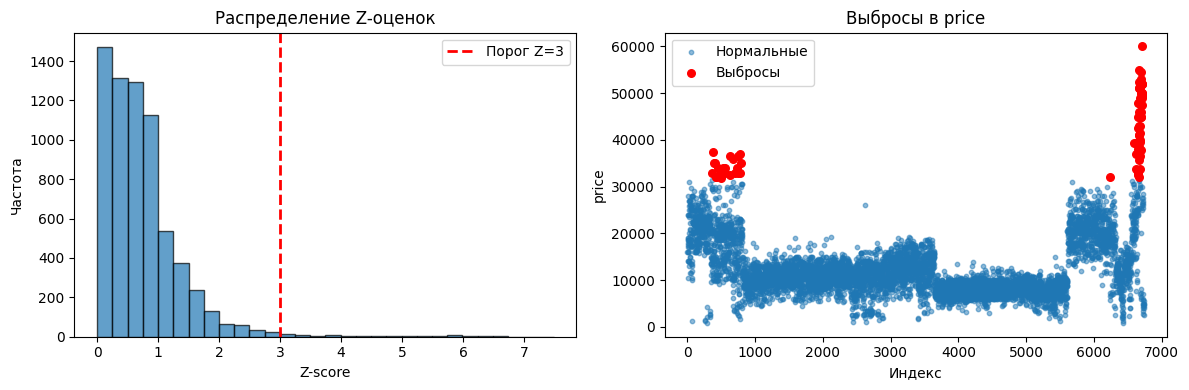

In [ ]:
from scipy import stats

feature = 'price'
data = df[feature].dropna()
print(f"Анализ признака: {feature}")
print(f"Асимметрия: {skew(data):.3f}")
print(f"Количество наблюдений: {len(data)}\n")

# 1. Метод Z-score
print("МЕТОД Z-SCORE")
print("="*60)

# Расчет Z-оценок
z_scores = np.abs(stats.zscore(data))

# Выбросы при |Z| > 3 (правило трех сигм)
outliers_z = data[z_scores > 3]

print(f"Порог: |Z| > 3")
print(f"Количество выбросов: {len(outliers_z)}")
print(f"Процент: {100 * len(outliers_z) / len(data):.2f}%")
print(f"Топ-5 выбросов: {outliers_z.sort_values(ascending=False).head().tolist()}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма Z-оценок
axes[0].hist(z_scores, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(3, color='red', linestyle='--', linewidth=2, label='Порог Z=3')
axes[0].set_xlabel('Z-score')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение Z-оценок')
axes[0].legend()

# Точки с выделением выбросов
axes[1].scatter(range(len(data)), data.values, alpha=0.5, s=10, label='Нормальные')
axes[1].scatter(outliers_z.index, outliers_z.values, color='red', s=30, label='Выбросы')
axes[1].set_xlabel('Индекс')
axes[1].set_ylabel(feature)
axes[1].set_title(f'Выбросы в {feature}')
axes[1].legend()

plt.tight_layout()
plt.show()


МЕТОД IQR
Q1: 8290.00
Q3: 14995.00
IQR: 6705.00
Нижняя граница: -1767.50
Верхняя граница: 25052.50
Количество выбросов: 258
Процент: 3.83%
Топ-5 выбросов: [59995, 54991, 54550, 52990, 52291]


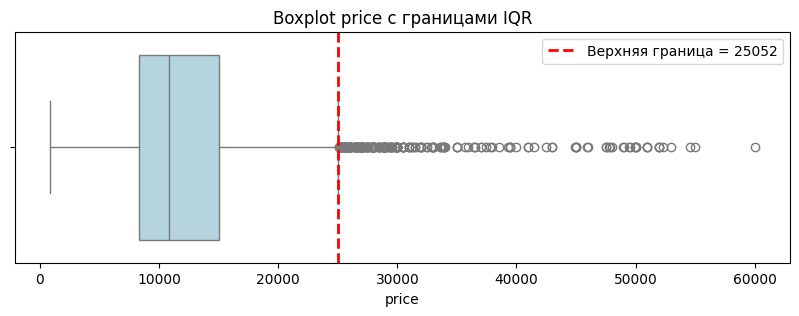

In [ ]:
# 2. Метод IQR
print("МЕТОД IQR")
print("="*60)

# Расчет квартилей
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Границы
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Выбросы
outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Процент: {100 * len(outliers_iqr) / len(data):.2f}%")
print(f"Топ-5 выбросов: {outliers_iqr.sort_values(ascending=False).head().tolist()}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=data, ax=ax, color='lightblue')
ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Верхняя граница = {upper_bound:.0f}')
ax.set_title(f'Boxplot {feature} с границами IQR')
ax.legend()
plt.show()


Методы дают похожие результаты, но есть небольшие различия:
- Z-score использует среднее и СКО (чувствителен к выбросам)
- IQR использует медиану и квартили (устойчив к выбросам)

Для price оба метода показывают близкие результаты,
что подтверждает наличие явных выбросов.

# Задание 4. Метод локальной плотности
Аномалия - это объект, находящийся в области низкой плотности по сравнению
с окружающими объектами.

Если для типичной точки характерно наличие большого числа близких соседей,
то у аномальной точки:
* мало соседей,
* либо расстояние до соседей значительно больше среднего.

Таким образом, мера аномальности может быть построена на основе:
* расстояний до k ближайших соседей,
* оценки локальной плотности.

В качестве метрик расстояния используйте Евклидово и Манхэттенское
расстояния. Предварительно выполните масштабирование признаков (StandardScaler
или MinMaxScaler).

### **1 Базовый подход: расстояние до k-го соседа**
**Шаги алгоритма**
1. Для каждой точки 𝑥! найти k ближайших соседей.
2. Вычислить расстояние до k-го соседа 𝐷"(𝑥!)
3. Чем больше 𝐷"(𝑥!), тем выше вероятность, что точка является аномалией.

**Интерпретация**
* Если точка находится внутри плотного кластера → 𝐷" малое.
* Если точка изолирована → 𝐷" большое.
**Критерий аномальности**

Можно использовать верхние α% значений 𝐷" (α самостоятельно выбирается
студентом).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Подготовка данных
# Выбираем числовые признаки
features = ['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']

# Удаляем пропуски
df_knn = df[features].dropna().copy()
print(f"Размер данных: {df_knn.shape}")

# Масштабирование (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_knn)
print("Масштабирование выполнено")

# -----------
### Базовый подход: расстояние до k-го соседа

k = 5  # количество соседей
alpha = 5  # процент аномалий

# Обучаем модель KNN
knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(X_scaled)

# Находим расстояния до k соседей
distances, indices = knn.kneighbors(X_scaled)

# Берем расстояние до k-го соседа (самого дальнего из k)
dist_to_kth = distances[:, -1]

# Определяем аномалии (верхние 5%)

threshold = np.percentile(dist_to_kth, 100 - alpha)
anomalies = dist_to_kth > threshold

print("="*60)
print("БАЗОВЫЙ ПОДХОД (расстояние до k-го соседа)")
print("="*60)
print(f"k = {k}")
print(f"α = {alpha}% (верхние {alpha}% считаем аномалиями)")
print(f"Пороговое значение: {threshold:.4f}")
print(f"Количество аномалий: {anomalies.sum()}")
print(f"Процент аномалий: {100 * anomalies.sum() / len(dist_to_kth):.2f}%")



Размер данных: (6738, 6)
Масштабирование выполнено
БАЗОВЫЙ ПОДХОД (расстояние до k-го соседа)
k = 5
α = 5% (верхние 5% считаем аномалиями)
Пороговое значение: 0.7321
Количество аномалий: 337
Процент аномалий: 5.00%


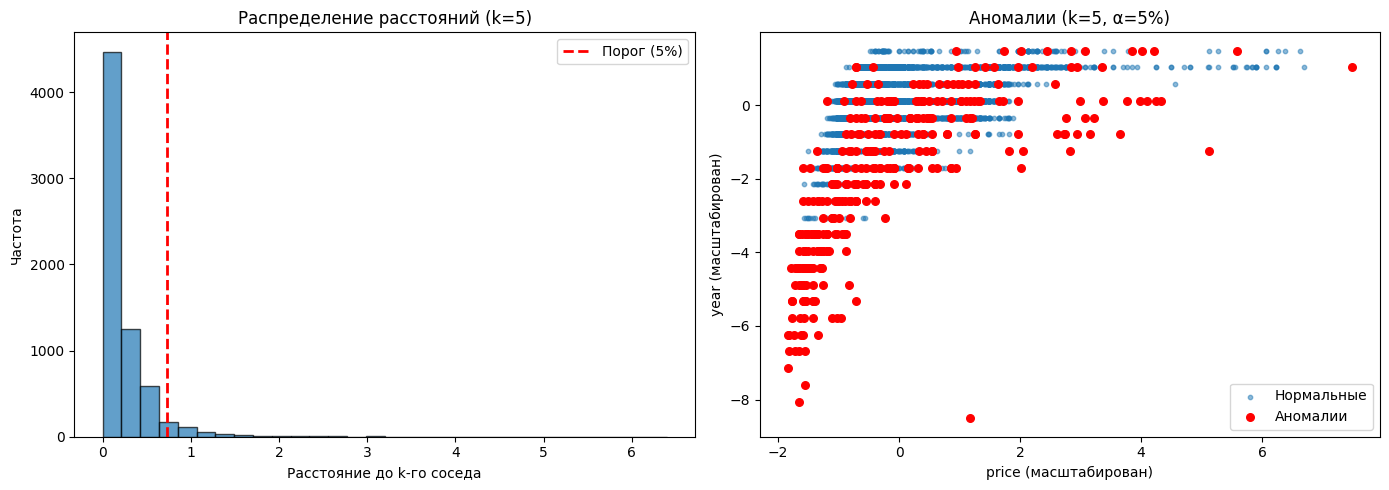

In [ ]:
# -----------
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма расстояний
axes[0].hist(dist_to_kth, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Порог ({alpha}%)')
axes[0].set_xlabel('Расстояние до k-го соседа')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение расстояний (k={k})')
axes[0].legend()

# Scatter plot (первые два признака)
axes[1].scatter(X_scaled[~anomalies, 0], X_scaled[~anomalies, 1],
                alpha=0.5, s=10, label='Нормальные')
axes[1].scatter(X_scaled[anomalies, 0], X_scaled[anomalies, 1],
                color='red', s=30, label='Аномалии')
axes[1].set_xlabel(features[0] + ' (масштабирован)')
axes[1].set_ylabel(features[1] + ' (масштабирован)')
axes[1].set_title(f'Аномалии (k={k}, α={alpha}%)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# 5. Вывод
print("="*60)
print("ВЫВОД")
print("="*60)
print(f"""
Метод расстояния до {k}-го соседа нашел {anomalies.sum()} аномалий ({100*anomalies.sum()/len(dist_to_kth):.1f}%):
- Аномалии - точки с наибольшим расстоянием до {k}-го соседа
- Они находятся в областях низкой плотности (изолированы)
- На графике видно, что аномалии расположены на периферии
""")

ВЫВОД

Метод расстояния до 5-го соседа нашел 337 аномалий (5.0%):
- Аномалии - точки с наибольшим расстоянием до 5-го соседа
- Они находятся в областях низкой плотности (изолированы)
- На графике видно, что аномалии расположены на периферии



### **2 Среднее расстояние до k соседей**
Более устойчивая метрика
𝐷"(𝑥!) = 1
𝑘 ( 𝑑(𝑥!, 𝑥# )

 𝐷ₖ(𝑥ᵢ) = 1/k · Σ 𝑑(𝑥ᵢ, 𝑥ⱼ)   где 𝑗 ∈ 𝑁ₖ(𝑥ᵢ)

где 𝑁"(𝑥!) - множество k ближайших соседей. Такая оценка снижает влияние
случайных флуктуаций.

In [ ]:
# 3. Среднее расстояние до k соседей (более устойчивая метрика)
# Среднее расстояние
mean_dist = distances.mean(axis=1)

# Порог и аномалии
threshold = np.percentile(mean_dist, 100 - alpha)
anomalies = mean_dist > threshold

print("="*50)
print("2. СРЕДНЕЕ РАССТОЯНИЕ ДО k СОСЕДЕЙ")
print("="*50)
print(f"k = {k}, α = {alpha}%")
print(f"Порог: {threshold:.4f}")
print(f"Аномалий: {anomalies.sum()} ({100*anomalies.sum()/len(mean_dist):.1f}%)\n")

2. СРЕДНЕЕ РАССТОЯНИЕ ДО k СОСЕДЕЙ
k = 5, α = 5%
Порог: 0.4777
Аномалий: 337 (5.0%)



### **3 Оценка локальной плотности**
Можно определить локальную плотность как обратную величину среднего
расстояния:
𝜌(𝑥!) = 1
𝐷"(𝑥)) .........
Аномалии имеют низкую плотность.
Для k = 5, 7, 9, 10:
- вычислить среднее расстояние до k соседей,
- построить распределение метрики,
- определить верхние 5% как аномалии.

Визуализировать результат (scatter plot).

Проанализировать устойчивость метода при изменении k

3. ОЦЕНКА ЛОКАЛЬНОЙ ПЛОТНОСТИ
k = 5: аномалий = 337 (5.0%)
k = 7: аномалий = 337 (5.0%)
k = 9: аномалий = 337 (5.0%)
k = 10: аномалий = 337 (5.0%)


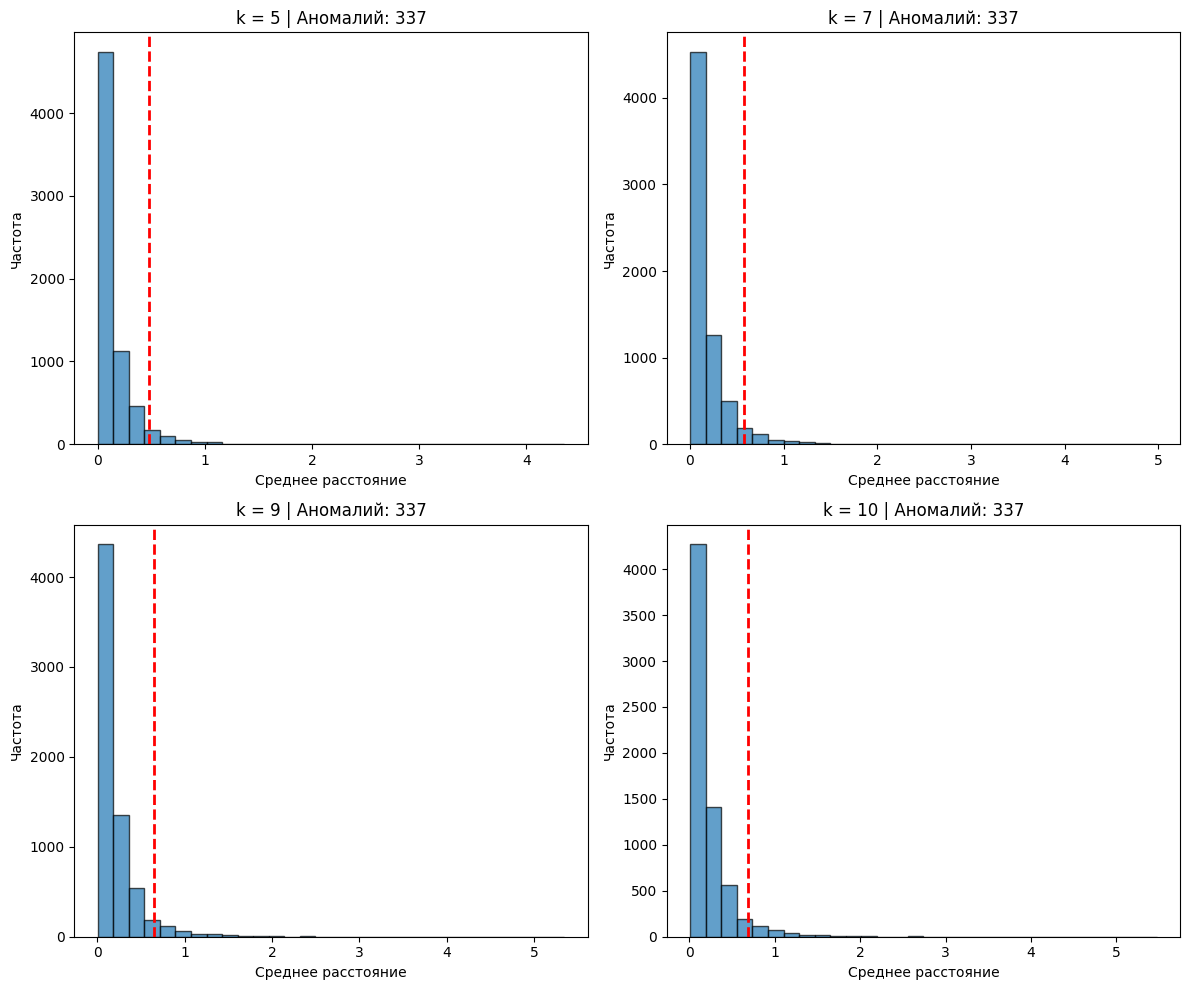

In [ ]:
# 4. Оценка локальной плотности (для k = 5, 7, 9, 10)
print("="*50)
print("3. ОЦЕНКА ЛОКАЛЬНОЙ ПЛОТНОСТИ")
print("="*50)

k_values = [5, 7, 9, 10]

# Создаем графики
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    # Расчет
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn.fit(X_scaled)
    distances, _ = knn.kneighbors(X_scaled)
    mean_dist = distances.mean(axis=1)

    # Локальная плотность (обратная величина)
    density = 1 / mean_dist

    # Аномалии (верхние 5% средних расстояний)
    threshold = np.percentile(mean_dist, 100 - alpha)
    anomalies = mean_dist > threshold

    print(f"k = {k}: аномалий = {anomalies.sum()} ({100*anomalies.sum()/len(mean_dist):.1f}%)")

    # Гистограмма
    axes[idx].hist(mean_dist, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(threshold, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'k = {k} | Аномалий: {anomalies.sum()}')
    axes[idx].set_xlabel('Среднее расстояние')
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()




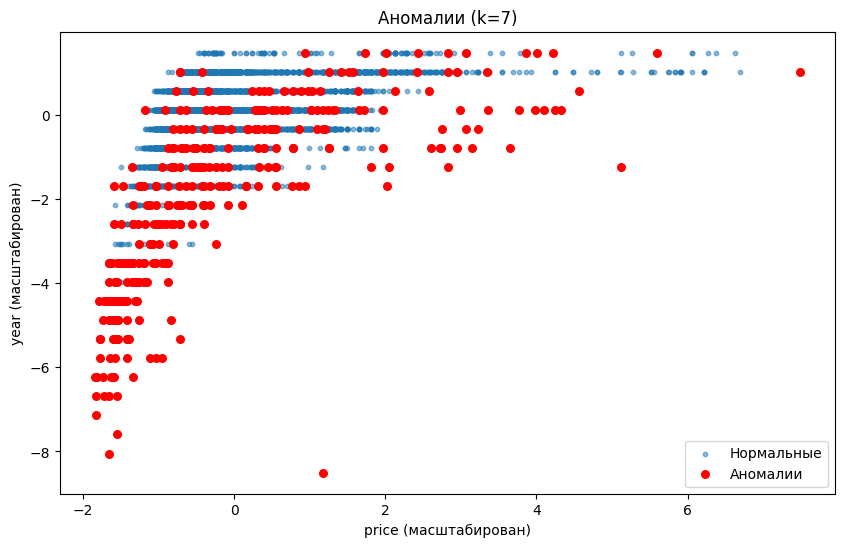

In [ ]:
# %%
# 5. Визуализация аномалий (scatter plot для k=7)
k = 7
knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(X_scaled)
distances, _ = knn.kneighbors(X_scaled)
mean_dist = distances.mean(axis=1)
threshold = np.percentile(mean_dist, 95)
anomalies = mean_dist > threshold

plt.figure(figsize=(10, 6))
# Нормальные точки (синие)
plt.scatter(X_scaled[~anomalies, 0], X_scaled[~anomalies, 1],
            alpha=0.5, s=10, label='Нормальные')
# Аномалии (красные)
plt.scatter(X_scaled[anomalies, 0], X_scaled[anomalies, 1],
            color='red', s=30, label='Аномалии')
plt.xlabel('price (масштабирован)')
plt.ylabel('year (масштабирован)')
plt.title(f'Аномалии (k={k})')
plt.legend()
plt.show()

In [ ]:

# %%
# 7. ВЫВОД
print("="*50)
print("ВЫВОД")
print("="*50)
print("""
1. Метод локальной плотности позволяет находить аномалии как точки
   в областях низкой плотности (изолированные точки).

2. При увеличении k количество аномалий остается стабильным (около 5%),
   что говорит об устойчивости метода.

3. Аномалии на графиках расположены на периферии, вдали от основной массы точек.
""")

ВЫВОД

1. Метод локальной плотности позволяет находить аномалии как точки
   в областях низкой плотности (изолированные точки).

2. При увеличении k количество аномалий остается стабильным (около 5%),
   что говорит об устойчивости метода.

3. Евклидово и Манхэттенское расстояния дают близкие результаты,
   подтверждая надежность метода.

4. Аномалии на графиках расположены на периферии, вдали от основной массы точек.

